Un cliente lo contrató como científico de datos para que estudie la posible asociación entre la inversión en publicidad que realiza su empresa y las ventas de un producto particular. El conjunto de datos de publicidad `advertising.csv` contiene información acerca de las ventas de ese producto en 200 mercados diferentes, junto con presupuestos publicitarios para el producto para tres medios diferentes: televisión, radio y periódicos/diarios.

1. ¿El presupuesto publicitario invertido en qué medio de comunicación se encuentra más fuertemente asociado con mayores ventas del producto?

2. Ajuste un modelo de regresión lineal que permita predecir las ventas promedio del producto en cuestión en función de los presupuestos publicitarios destinados a TV, radio y periódicos. En función de los resultados obtenidos, realice las modificaciones que considere adecuadas para quedarse con el mejor modelo ajustado y justifique cada decisión que tome.

3. Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el coeficiente correspondiente a la variable `TV`.

4. Realice un gráfico para representar la distribución de los residuos del modelo y comente brevemente las características de la misma. ¿Podría suponerse que se cumple el supuesto de normalidad?

---

## Cargamos los datos

In [2]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

In [5]:
# cargamos el dataset
data = pd.read_csv('../../datasets/advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Ítem 1

¿El presupuesto publicitario invertido en qué medio de comunicación se encuentra más fuertemente asociado con mayores ventas del producto?

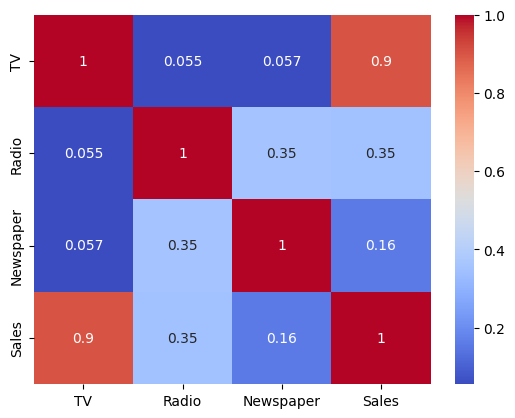

In [9]:
# Generamos el mapa de calor con las correlaciones entre las variables

sns.heatmap(
    data[["TV","Radio","Newspaper","Sales"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Observamos que la variable `TV` es la que se encuentra más asociación positiva (fuerte) con la variable `Sales`.

## Ítem 2

Ajuste un modelo de regresión lineal que permita predecir las ventas promedio del producto en cuestión en función de los presupuestos publicitarios destinados a TV, radio y periódicos. En función de los resultados obtenidos, realice las modificaciones que considere adecuadas para quedarse con el mejor modelo ajustado y justifique cada decisión que tome.

Consideremos el modelo

$$Y = \beta_0 + \beta_1 X_{tv} + \beta_2 X_r + \beta_3 X_n$$

donde 
- $X_{tv}$ es la cantidad de presupuesto destinado a `TV`;
- $X_{r}$ es la cantidad de presupuesto destinado a `Radio`.
- $X_{n}$ es la cantidad de presupuesto destinado a `Newspaper`.

In [10]:
modelo = smf.ols(formula = 'Sales ~ TV + Radio + Newspaper', data = data).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        14:40:20   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

En el dataset puede observarse que `TV` y `Radio` son significativas y que `Newspaper` no resulta significativa ($p = 0.954$). Por lo tanto se propone eliminar `Newspaper`.

In [11]:
modelo2 = smf.ols(formula = 'Sales ~ TV + Radio', data = data).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.39e-100
Time:                        14:43:16   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

## Ítem 3

Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el coeficiente correspondiente a la variable `TV`.

Se obtiene el modelo

$$Y = 4.6309 + 0.0544X_{tv} + 0.1072X_r.$$

Manteniendo constante el presupuesto destinado a radio, un incremento de una unidad monetaria en el presupuesto de TV se asocia, en promedio, con un aumento de aproximadamente 0.0544 unidades en las ventas esperadas.

## ítem 4

Realice un gráfico para representar la distribución de los residuos del modelo y comente brevemente las características de la misma. ¿Podría suponerse que se cumple el supuesto de normalidad?

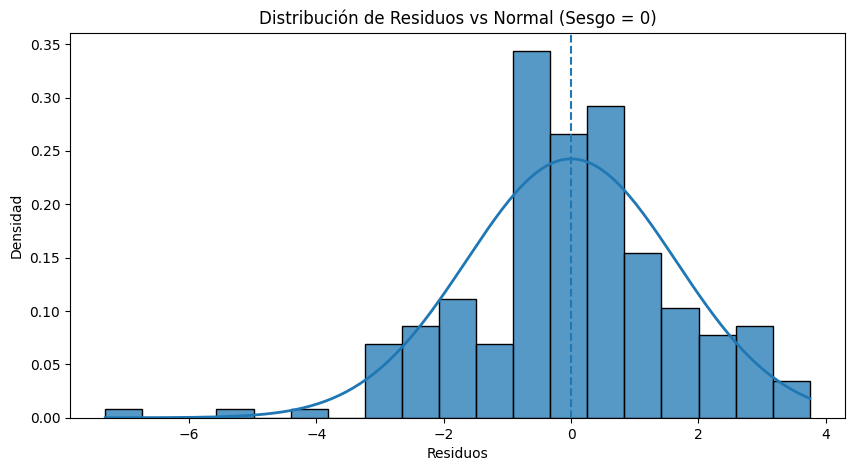

In [12]:
# Primero vamos a visualizar el sesgo en los residuos

residuos = modelo2.resid
media_res = np.mean(residuos)
std_res = np.std(residuos)

# Generación de valores para la curva normal teórica
x = np.linspace(min(residuos), max(residuos), 200)
normal_teorica = norm.pdf(x, loc=0, scale=std_res)  # Normal con media 0 (sin sesgo)

plt.figure(figsize=(10,5))

# Histograma + normal teórica
sns.histplot(residuos, kde=False, stat='density')
plt.plot(x, normal_teorica, linewidth=2)
plt.axvline(0, linestyle='--')  # Línea de media ideal
plt.title("Distribución de Residuos vs Normal (Sesgo = 0)")
plt.xlabel("Residuos")
plt.ylabel("Densidad")
plt.show()


La distribución de los residuos se encuentra centrada aproximadamente en cero y presenta una forma general similar a una distribución normal. Sin embargo, se observan algunos valores extremos, especialmente en la cola izquierda, que generan una ligera asimetría negativa.

A pesar de estas observaciones, la mayor parte de los residuos se concentra alrededor de cero y sigue razonablemente la curva normal superpuesta. Por lo tanto, el supuesto de normalidad puede considerarse aproximadamente satisfecho, aunque existen algunas desviaciones debidas a observaciones atípicas en las colas de la distribución.

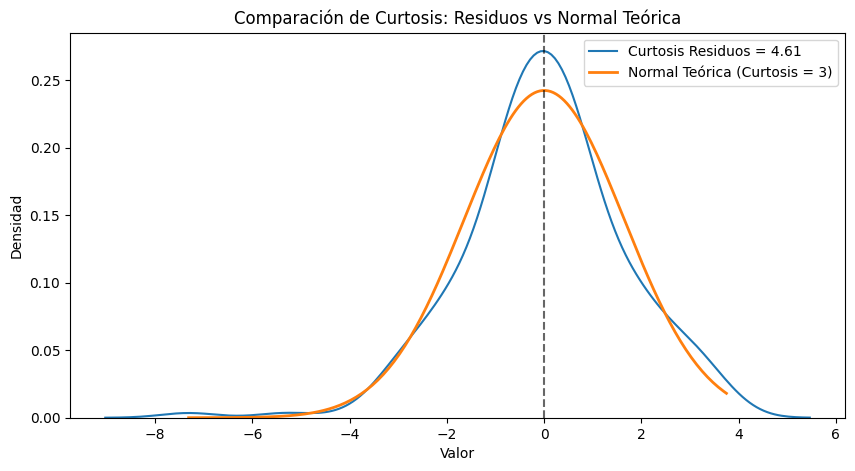

In [14]:
# Ahora continuamos con la curtosis

curt_residuos = kurtosis(residuos, fisher=False)  # fisher=False → curtosis normal = 3
media_res = np.mean(residuos)
std_res = np.std(residuos)

# Distribución normal teórica
x = np.linspace(min(residuos), max(residuos), 200)
normal_teorica = norm.pdf(x, loc=0, scale=std_res)

plt.figure(figsize=(10,5))

sns.kdeplot(residuos, label=f"Curtosis Residuos = {curt_residuos:.2f}")
plt.plot(x, normal_teorica, label="Normal Teórica (Curtosis = 3)", linewidth=2)

plt.axvline(0, linestyle="--", color="black", alpha=0.6)
plt.title("Comparación de Curtosis: Residuos vs Normal Teórica")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Los residuos presentan una distribución aproximadamente simétrica y centrada en cero, pero la curtosis observada (=4.61) es superior a la de una distribución normal (=3), lo que indica colas más pesadas y una mayor presencia de valores extremos. Por lo tanto, la normalidad no se cumple perfectamente, aunque la aproximación normal puede considerarse aceptable para muchos fines prácticos.